<a href="https://colab.research.google.com/github/amelyssaeu-ab/bio-dkm/blob/main/tarefa07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa 07 - Semana 4
### Espécies de Plantas, Biomassa e pH

##### Drielly Mathias Albertti - nº 16831084
##### Kawana Ganeo de Carvalho - nº 14669691
##### Melyssa Ponce Lopes - nº 16831017


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import statsmodels.formula.api as smf
sns.set_style("whitegrid")

Relação gráfica entre biomassa e número de espécies

In [14]:
df = pd.read_csv('Tarefa_Semana4.csv', sep='\t')
ph_map = {'low': 1, 'mid': 2, 'high': 3}
df['pH_num'] = df['pH'].map(ph_map)

# Convert 'pH' column to an ordered categorical type
ph_order = ['low', 'mid', 'high']
df['pH'] = pd.Categorical(df['pH'], categories=ph_order, ordered=True)

df.head()

,pH,Biomass,Species,pH_num
0,high,0.469297,30,3
1,high,1.730870,39,3
2,high,2.089778,44,3
3,high,3.925787,35,3
4,high,4.366793,25,3


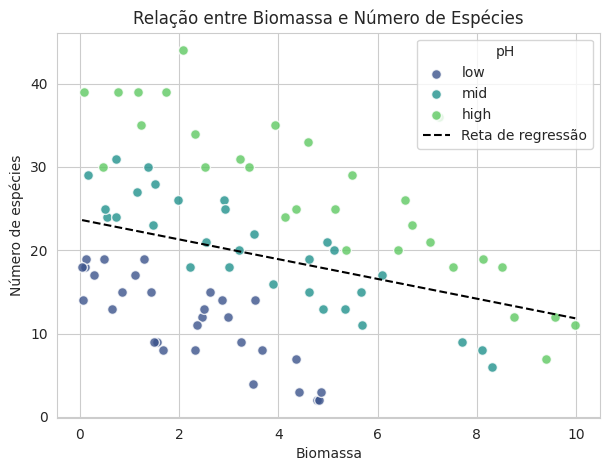

In [8]:
fig, ax = plt.subplots(figsize=(7,5))
palette = dict(zip(['low','mid','high'], sns.color_palette("viridis", 3)))
for level in ['low','mid','high']:
    sub = df[df['pH'] == level]
    ax.scatter(sub['Biomass'], sub['Species'], label=level, color=palette[level],
               alpha=0.8, edgecolor='white', s=50)
slope, intercept, r, p, se = stats.linregress(df['Biomass'], df['Species'])
xs = np.linspace(df['Biomass'].min(), df['Biomass'].max(), 100)
ax.plot(xs, intercept + slope*xs, color='black', linestyle='--', linewidth=1.5, label='Reta de regressão')
ax.set_xlabel("Biomassa")
ax.set_ylabel("Número de espécies")
ax.set_title("Relação entre Biomassa e Número de Espécies")
ax.legend(title="pH")
plt.show()

# **Resposta pergunta 1.**
Graficamente, a relação aparece como uma nuvem de pontos com tendência de queda, ou seja, um decréscimo aproximadamente linear (mas com bastante dispersão) do número de espécies à medida que a biomassa cresce.

# **Resposta pergunta 2.**
O gráfico de dispersão sugere uma **associação negativa** entre biomassa e número de espécies, quanto maior a biomassa, menor tende a ser o número de espécies na parcela.

A correlação de Pearson calculada foi: **r = -0,317**

## 3. Relação entre pH e número de espécies

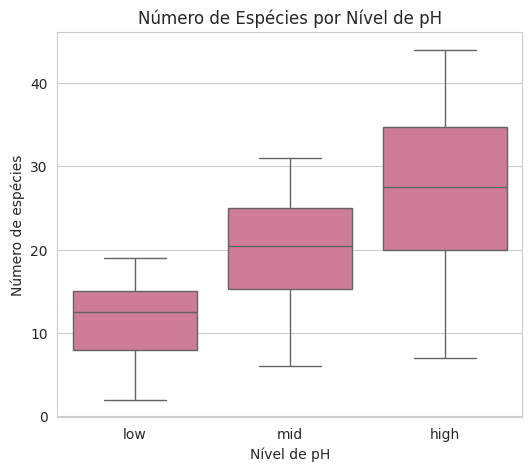

In [10]:
fig, ax = plt.subplots(figsize=(6,5))
sns.boxplot(data=df, x='pH', y='Species', order=['low','mid','high'], color='palevioletred', ax=ax)
ax.set_xlabel("Nível de pH")
ax.set_ylabel("Número de espécies")
ax.set_title("Número de Espécies por Nível de pH")
plt.show()

# **Resposta pergunta 3.**
Sim, há evidência de uma relação linear (crescente) entre o pH e o número de espécies. Ao tratar os níveis de pH como uma escala ordinal crescente (baixo=1, médio=2, alto=3), a correlação de Pearson entre pH e número de espécies é **r ≈ 0.646** (positiva e moderada/forte), com p < 0,001, a tendência de aumento é estatisticamente significativa.

O número de espécies aumenta conforme o pH sobe de baixo para alto (médias aproximadas: baixo ≈ 11,6; médio ≈ 20,0; alto ≈ 26,8 espécies)

In [18]:
modelo_biomassa = smf.ols('Species ~ Biomass', data=df).fit()
print(modelo_biomassa.summary())

                            OLS Regression Results                            
Dep. Variable:                Species   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     9.839
Date:                Thu, 27 Aug 2026   Prob (F-statistic):            0.00232
Time:                        00:31:53   Log-Likelihood:                -326.73
No. Observations:                  90   AIC:                             657.5
Df Residuals:                      88   BIC:                             662.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.6755      1.660     14.259      0.0

#**Resposta pergunta 4.**
Sim, é possível utilizar um modelo de regressão linear simples para prever o número de espécies a partir da quantidade de biomassa.



O modelo estimado foi: ŷ=23,6755−1,1864X

em que:

Y= número estimado de espécies;

X= quantidade de biomassa.

O modelo foi estatisticamente significativo (p = 0,0023).

Entretanto, o R² foi de apenas 0,1006, indicando que a biomassa explica aproximadamente 10,06% da variação no número de espécies. Portanto, embora exista uma relação significativa, a biomassa sozinha possui capacidade limitada de previsão.



# **Resposta pergunta 5.**
Usando a codificação ordinal do pH (baixo=1, médio=2, alto=3), a equação da reta de regressão é:

    pH baixo (1) → aproximadamente 11,84 espécies
    pH médio (2) → aproximadamente 19,46 espécies
    pH alto (3) → aproximadamente 27,07 espécies

Os valores previstos são próximos às médias observadas dos grupos, que foram aproximadamente 11,57, 20,00 e 26,80 espécies, respectivamente.

# **Resposta pergunta 6.**

O intercepto estimado é ≈ **23.68**. Ele representa o número esperado de espécies quando a biomassa é igual a zero. Como o valor mínimo observado de biomassa nos dados é próximo de zero (mín. ≈ 0,05), o intercepto tem uma interpretação prática razoável: em uma parcela com biomassa praticamente nula, espera-se, em média, cerca de 24 espécies de plantas.

#**Resposta pergunta 7.**
O coeficiente de inclinação estimado é ≈ **-1.186**. Isso indica que, para cada unidade adicional de biomassa, o número esperado de espécies de plantas **diminui**, em média, cerca de 1.19 espécies, mantendo os demais fatores constantes. O sinal negativo confirma a associação negativa observada no gráfico de dispersão.

#**Resposta pergunta 8.**
Sim. O teste t para o coeficiente de inclinação da regressão Espécies ~ Biomassa resulta em p ≈ 0.0023 (p < 0,05), o que indica que o efeito da biomassa sobre o número de espécies é **estatisticamente significativo**, rejeitamos a hipótese nula de que a inclinação é igual a zero.

# **Resposta pergunta 9.**
O coeficiente de determinação (R²) do modelo Espécies ~ pH (codificado ordinalmente) é **R² ≈ 0.417**, ou seja, aproximadamente **41.7%** da variação observada no número de espécies pode ser explicada pelos níveis de pH nesse modelo linear. Os 58.3% restantes são atribuídos a outros fatores não incluídos no modelo (como a própria biomassa e variação natural entre parcelas).

#**Resposta pergunta 10.**
Sim, existe correlação linear estatisticamente significativa entre biomassa e número de espécies: **r ≈ -0.317** (negativa e fraca a moderada), com **p ≈ 0.0023** (p < 0,05). Como o p-valor é menor que 0,05, rejeitamos a hipótese nula de correlação nula, a associação negativa observada não é atribuível ao acaso.

In [21]:
r_ph, p_ph = stats.pearsonr(df['pH_num'], df['Species'])
print(f"r de Pearson = {r_ph:.4f}")
print(f"p-valor = {p_ph:.2e}")

r de Pearson = 0.6461
p-valor = 6.11e-12


#**Resposta pergunta 11.**
A correlação de Pearson entre pH (codificado ordinalmente) e número de espécies é **r ≈ 0.646**, com p < 0,001. Isso indica uma correlação **positiva e de intensidade moderada a forte**: quanto maior o pH do solo, maior tende a ser o número de espécies de plantas na parcela.